# VAR Parameter Estimation

The Vector Auto Regressive Process is a generalization of the single variable Autoregressive (AR) process to multiple variables. The $\text{VAR}(n)$ </br> 
is defined by,

$
\begin{align}
X_t = \mathcal{M} + \Phi_1 X_{t-1} \Phi_2 X_{t-2} + \cdots + \Phi_n X_{t-n} + \mathcal{E}_t
\end{align}
\tag{1}
$

where $t = 1, 2, 3, \ldots, T$, $X_t$ is column vector of length $m$ representing the time series, $\mathcal{M}$ is a $m$ element constant offset column vector, $\Phi_t$ are $m \times m$ matrices denoting constant coefficients and $\mathcal{E}_t$ an a random column normal vector with zero mean and covariance matrix $\Omega$,

$
\begin{align}
\mathcal{E}_t \sim \text{Normal}(0, \Omega)
\end{align}
\tag{2}
$

It follows that,

$
\begin{align}
\text{Cov}(\mathcal{E}_t, \mathcal{E}_s) = \Omega 
\end{align}
\tag{3}
$

Given a multivariate time series $X_t$ the following parameters are estimated: $\mathcal{M}$, $\Phi_n$ and $\Omega$. Here simulations are performed for specified values of the parameters and estimation methods the take the simulated $X_t$ as input are tested by comparing the result to the values specified .

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot
import numpy

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import var, stats
from lib.plots import stack, fpoints, fcurve, PlotType

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
def comparison_plot(xt, title, ylim=(-2.5, 2.5), xlim=(0, 1000)):
    ylabels = [f"$S_{i+1}(t)$" for i in range(len(xt))]
    stack(xt, ylim=ylim, xlim=xlim, title=title, ylabels=ylabels, xlabel=r"$t$", figsize=(10, 6), title_offset=0.2, lw=1)

## $\text{VAR}(1)$ Simulations

### Uncoupled $\text{AR}(1)$

In [3]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.0],
                      [0.0, 0.25]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])

npts=5000
nlag=1
var.compute_is_stationary(phi)

True

In [4]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

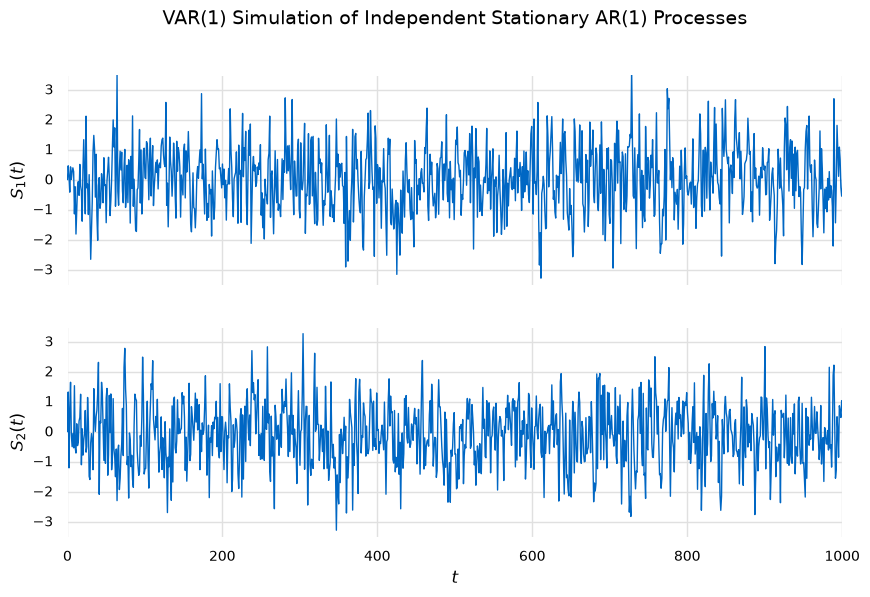

In [5]:
title = f"VAR(1) Simulation of Independent Stationary AR(1) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [6]:
result, result_model = var.compute_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.1674,0.1700,1.182,0.1683
1,0.02371*,0.03154*,1.024*,0.02646*
2,0.02502,0.03806,1.025,0.02959
3,0.02565,0.04391,1.026,0.03205
4,0.02651,0.04999,1.027,0.03474


In [7]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "ec6a3a2d-1015-40cb-aae3-8de4ce9e64cb",
   "_VAROrderTestReport__order": {
      "test_id": "ec6a3a2d-1015-40cb-aae3-8de4ce9e64cb",
      "label": "$\\tau_{min}$",
      "value": 1
   },
   "_VAROrderTestReport__aic": {
      "test_id": "ec6a3a2d-1015-40cb-aae3-8de4ce9e64cb",
      "order": {
         "test_id": "ec6a3a2d-1015-40cb-aae3-8de4ce9e64cb",
         "label": "$\\tau_{AIC}$",
         "value": 1
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "ec6a3a2d-1015-40cb-aae3-8de4ce9e64cb",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.02371311292302146
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "ec6a3a2d-1015-40cb-aae3-8de4ce9e64cb",
      "order": {
         "test_id": "ec6a3a2d-1015-40cb-aae3-8de4ce9e64cb",
         "label": "$\\tau_{BIC}$",
         "value": 1
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "ec6a3a2d-1015-40cb-aae3-8de4ce9e64cb",
        

In [8]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 23, Aug, 2026
Time:                     17:31:20
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  0.0314869
Nobs:                     4999.00    HQIC:                 0.0264065
Log likelihood:          -14239.7    FPE:                    1.02395
AIC:                    0.0236650    Det(Omega_mle):         1.02272
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.005734         0.014216            0.403           0.687
L1.y1         0.248763         0.013703           18.153           0.000
L1.y2        -0.009282         0.013571           -0.684           0.494

Results for equation 

In [9]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VAR",
   "const": [
      {
         "est": 0.005733788744466639,
         "err": 0.014216307623186712,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "33d5a592-5c11-4c59-814f-5f21dea4527e",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.00942370321043039,
         "err": 0.014233160878866282,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 2,
         "est_id": "33d5a592-5c11-4c59-814f-5f21dea4527e",
         "param_type": "VAR_CONST"
      }
   ],
   "order": 1,
   "params": [
      {
         "est": 0.24876326537627727,
         "err": 0.013703364475765117,
         "est_label": "$\\hat{\\Phi}$",
         "err_label": "$\\sigma^\\Phi$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "33d5a592-5c11-4c59-814f-5f21dea4527e"

### Coupled $\text{AR}(1)$

In [10]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.05],
                      [0.5, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=1
var.compute_is_stationary(phi)

True

In [11]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

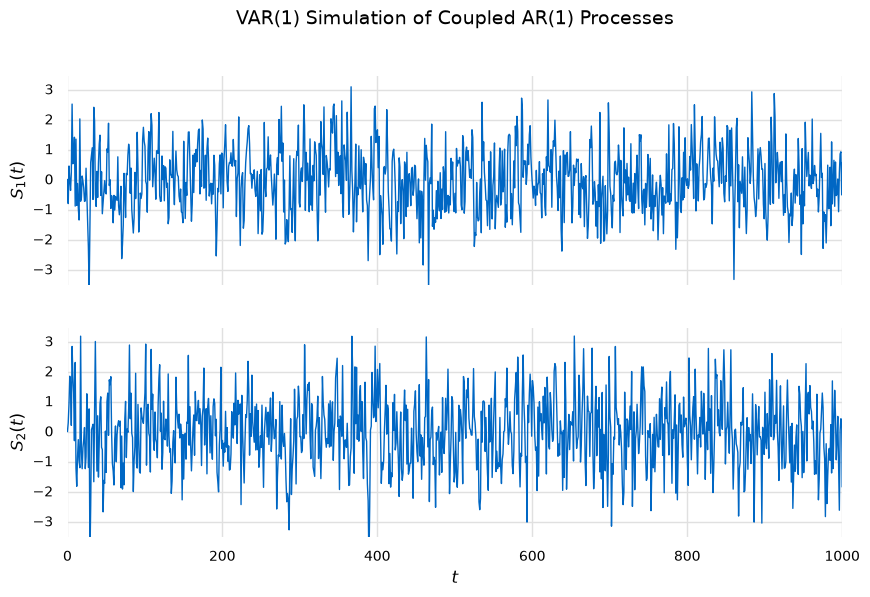

In [12]:
title = f"VAR(1) Simulation of Coupled AR(1) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [13]:
result, result_model = var.compute_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.3213,0.3239,1.379,0.3222
1,-0.01002*,-0.002191*,0.9900*,-0.007274*
2,-0.009364,0.003679,0.9907,-0.004793
3,-0.008065,0.01020,0.9920,-0.001665
4,-0.008254,0.01522,0.9918,-2.524e-05


In [14]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "39373884-383b-4cb9-a924-922b5898cd43",
   "_VAROrderTestReport__order": {
      "test_id": "39373884-383b-4cb9-a924-922b5898cd43",
      "label": "$\\tau_{min}$",
      "value": 1
   },
   "_VAROrderTestReport__aic": {
      "test_id": "39373884-383b-4cb9-a924-922b5898cd43",
      "order": {
         "test_id": "39373884-383b-4cb9-a924-922b5898cd43",
         "label": "$\\tau_{AIC}$",
         "value": 1
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "39373884-383b-4cb9-a924-922b5898cd43",
         "label": "$\\varepsilon_{AIC}$",
         "value": -0.01001654180201842
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "39373884-383b-4cb9-a924-922b5898cd43",
      "order": {
         "test_id": "39373884-383b-4cb9-a924-922b5898cd43",
         "label": "$\\tau_{BIC}$",
         "value": 1
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "39373884-383b-4cb9-a924-922b5898cd43",
       

In [15]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 23, Aug, 2026
Time:                     17:31:20
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                -0.00241625
Nobs:                     4999.00    HQIC:               -0.00749670
Log likelihood:          -14155.0    FPE:                   0.989814
AIC:                   -0.0102382    Det(Omega_mle):        0.988627
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.018878         0.014067           -1.342           0.180
L1.y1         0.270415         0.013749           19.668           0.000
L1.y2         0.043127         0.012413            3.474           0.001

Results for equation 

In [16]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VAR",
   "const": [
      {
         "est": -0.018877986608306235,
         "err": 0.014067402208709738,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "ab55f3f5-2a6a-479f-a5e4-f51be4d38697",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.022682251756246174,
         "err": 0.014155265298485726,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 2,
         "est_id": "ab55f3f5-2a6a-479f-a5e4-f51be4d38697",
         "param_type": "VAR_CONST"
      }
   ],
   "order": 1,
   "params": [
      {
         "est": 0.2704146085769949,
         "err": 0.013749246795912587,
         "est_label": "$\\hat{\\Phi}$",
         "err_label": "$\\sigma^\\Phi$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "ab55f3f5-2a6a-479f-a5e4-f51be4d38697

### Coupled $\text{AR}(1)$ With Non Unit Normal Noise

In [17]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.05],
                      [0.5, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[2.0, 0.2],
                      [0.2, 2.0]])
npts=5000
nlag=1
var.compute_is_stationary(phi)

True

In [18]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

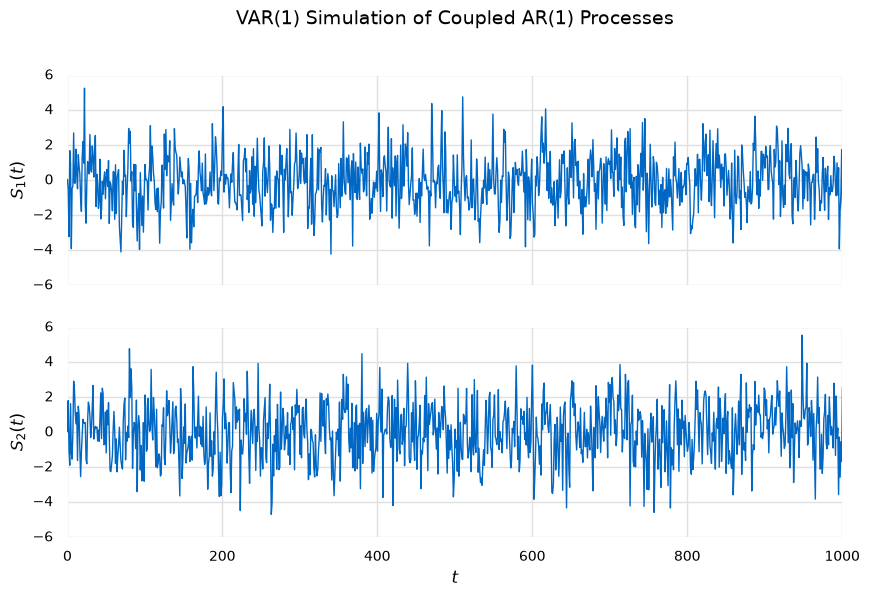

In [19]:
title = f"VAR(1) Simulation of Coupled AR(1) Processes"
comparison_plot(xt, title, ylim=(-6.0, 6.0))

In [20]:
result, result_model = var.compute_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,1.723,1.726,5.601,1.724
1,1.405*,1.413*,4.076*,1.408*
2,1.406,1.419,4.079,1.410
3,1.407,1.425,4.083,1.413
4,1.408,1.431,4.087,1.416


In [21]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "b2ad8303-5eba-4fb9-b76c-fe187552f46c",
   "_VAROrderTestReport__order": {
      "test_id": "b2ad8303-5eba-4fb9-b76c-fe187552f46c",
      "label": "$\\tau_{min}$",
      "value": 1
   },
   "_VAROrderTestReport__aic": {
      "test_id": "b2ad8303-5eba-4fb9-b76c-fe187552f46c",
      "order": {
         "test_id": "b2ad8303-5eba-4fb9-b76c-fe187552f46c",
         "label": "$\\tau_{AIC}$",
         "value": 1
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "b2ad8303-5eba-4fb9-b76c-fe187552f46c",
         "label": "$\\varepsilon_{AIC}$",
         "value": 1.4050723385493848
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "b2ad8303-5eba-4fb9-b76c-fe187552f46c",
      "order": {
         "test_id": "b2ad8303-5eba-4fb9-b76c-fe187552f46c",
         "label": "$\\tau_{BIC}$",
         "value": 1
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "b2ad8303-5eba-4fb9-b76c-fe187552f46c",
         

In [22]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 23, Aug, 2026
Time:                     17:31:21
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    1.41377
Nobs:                     4999.00    HQIC:                   1.40869
Log likelihood:          -17694.7    FPE:                    4.07941
AIC:                      1.40595    Det(Omega_mle):         4.07451
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.009457         0.019970           -0.474           0.636
L1.y1         0.257265         0.013965           18.423           0.000
L1.y2         0.033193         0.012359            2.686           0.007

Results for equation 

In [23]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VAR",
   "const": [
      {
         "est": -0.009456599926046793,
         "err": 0.01997041817664963,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "ecb54afa-a2b3-4aea-81f5-eb3106241511",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.02613511781851954,
         "err": 0.02033567601837156,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 2,
         "est_id": "ecb54afa-a2b3-4aea-81f5-eb3106241511",
         "param_type": "VAR_CONST"
      }
   ],
   "order": 1,
   "params": [
      {
         "est": 0.2572646855700085,
         "err": 0.013964690946463697,
         "est_label": "$\\hat{\\Phi}$",
         "err_label": "$\\sigma^\\Phi$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "ecb54afa-a2b3-4aea-81f5-eb3106241511",


## $\text{VAR}(2)$ Simulations
### Uncoupled $\text{AR}(2)$

In [24]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.0],
                      [0.0, 0.25]]),
        numpy.matrix([[0.5, 0.0],
                      [0.0, 0.5]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=2
var.compute_is_stationary(phi)

True

In [25]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

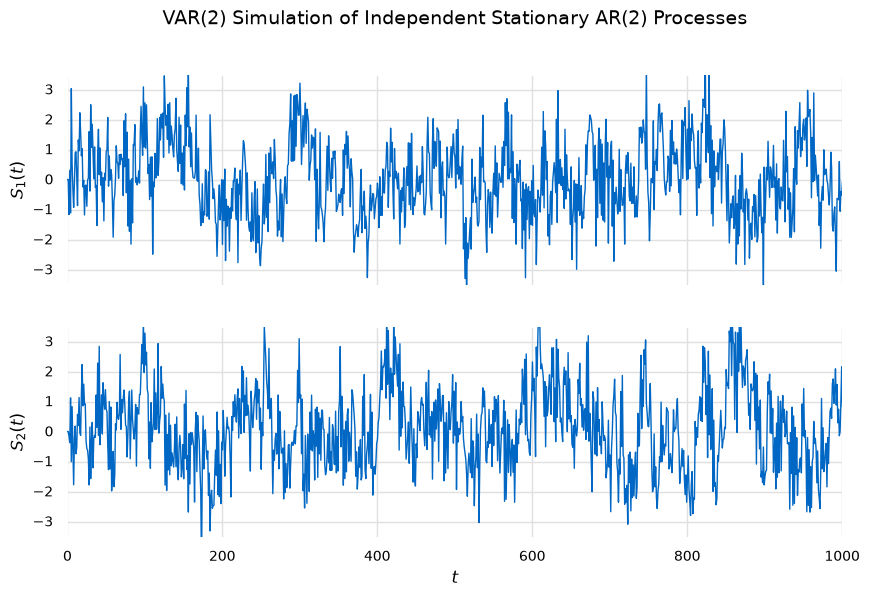

In [26]:
title = f"VAR(2) Simulation of Independent Stationary AR(2) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [27]:
result, result_model = var.compute_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,1.134,1.137,3.108,1.135
1,0.5743,0.5821,1.776,0.5770
2,-0.02378*,-0.01074*,0.9765*,-0.01921*
3,-0.02309,-0.004830,0.9772,-0.01669
4,-0.02185,0.001625,0.9784,-0.01362


In [28]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "3321d0b6-d0e9-4017-9119-7e78f7e293a9",
   "_VAROrderTestReport__order": {
      "test_id": "3321d0b6-d0e9-4017-9119-7e78f7e293a9",
      "label": "$\\tau_{min}$",
      "value": 2
   },
   "_VAROrderTestReport__aic": {
      "test_id": "3321d0b6-d0e9-4017-9119-7e78f7e293a9",
      "order": {
         "test_id": "3321d0b6-d0e9-4017-9119-7e78f7e293a9",
         "label": "$\\tau_{AIC}$",
         "value": 2
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "3321d0b6-d0e9-4017-9119-7e78f7e293a9",
         "label": "$\\varepsilon_{AIC}$",
         "value": -0.023780785847529472
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "3321d0b6-d0e9-4017-9119-7e78f7e293a9",
      "order": {
         "test_id": "3321d0b6-d0e9-4017-9119-7e78f7e293a9",
         "label": "$\\tau_{BIC}$",
         "value": 2
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "3321d0b6-d0e9-4017-9119-7e78f7e293a9",
      

In [29]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 23, Aug, 2026
Time:                     17:31:21
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                 -0.0111626
Nobs:                     4998.00    HQIC:                -0.0196314
Log likelihood:          -14113.2    FPE:                   0.976089
AIC:                   -0.0242014    Det(Omega_mle):        0.974139
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.013862         0.014013            0.989           0.323
L1.y1         0.240906         0.012129           19.862           0.000
L1.y2         0.020805         0.012132            1.715           0.086
L2.y1         0.515283

In [30]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VAR",
   "const": [
      {
         "est": 0.013861646611398451,
         "err": 0.014012852885637554,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "e34c0d14-00a5-4e00-88c8-ebd98390a51c",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.005881058198133104,
         "err": 0.01413892746972726,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 2,
         "est_id": "e34c0d14-00a5-4e00-88c8-ebd98390a51c",
         "param_type": "VAR_CONST"
      }
   ],
   "order": 2,
   "params": [
      {
         "est": 0.24090645988774279,
         "err": 0.012129251579028858,
         "est_label": "$\\hat{\\Phi}$",
         "err_label": "$\\sigma^\\Phi$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "e34c0d14-00a5-4e00-88c8-ebd98390a51c

### Coupled $\text{AR}(2)$

In [31]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.15],
                      [0.1, 0.1]]),
        numpy.matrix([[0.25, 0.3],
                      [0.2, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=2
var.compute_is_stationary(phi)

True

In [32]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

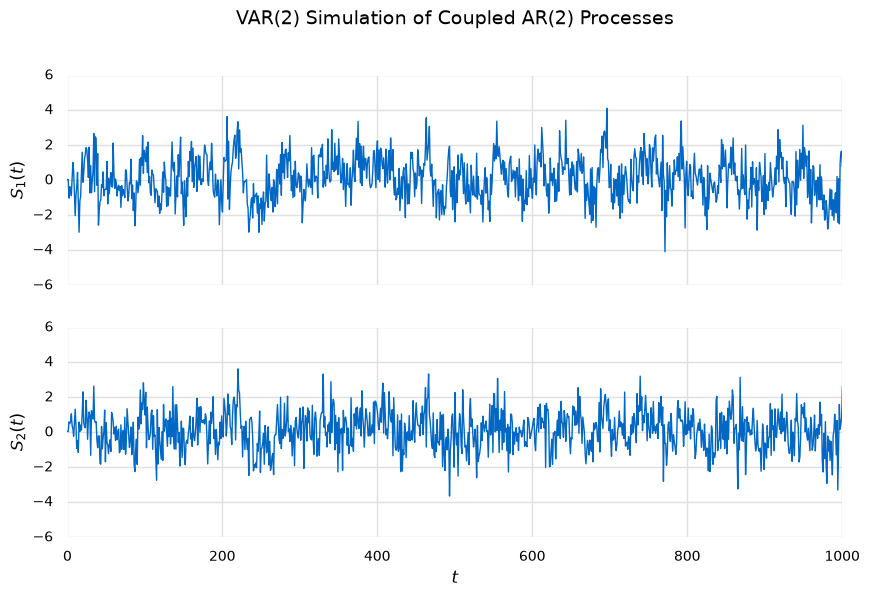

In [33]:
title = f"VAR(2) Simulation of Coupled AR(2) Processes"
comparison_plot(xt, title, ylim=(-6.0, 6.0))

In [34]:
result, result_model = var.compute_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.4546,0.4572,1.576,0.4555
1,0.2218,0.2296,1.248,0.2245
2,0.003361*,0.01640*,1.003*,0.007933*
3,0.004385,0.02265,1.004,0.01079
4,0.005363,0.02884,1.005,0.01359


In [35]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "5bd208a3-a900-41b8-a273-a54189901c0d",
   "_VAROrderTestReport__order": {
      "test_id": "5bd208a3-a900-41b8-a273-a54189901c0d",
      "label": "$\\tau_{min}$",
      "value": 2
   },
   "_VAROrderTestReport__aic": {
      "test_id": "5bd208a3-a900-41b8-a273-a54189901c0d",
      "order": {
         "test_id": "5bd208a3-a900-41b8-a273-a54189901c0d",
         "label": "$\\tau_{AIC}$",
         "value": 2
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "5bd208a3-a900-41b8-a273-a54189901c0d",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.003361419025099781
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "5bd208a3-a900-41b8-a273-a54189901c0d",
      "order": {
         "test_id": "5bd208a3-a900-41b8-a273-a54189901c0d",
         "label": "$\\tau_{BIC}$",
         "value": 2
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "5bd208a3-a900-41b8-a273-a54189901c0d",
       

In [36]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 23, Aug, 2026
Time:                     17:31:21
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  0.0159546
Nobs:                     4998.00    HQIC:                0.00748579
Log likelihood:          -14181.0    FPE:                    1.00292
AIC:                   0.00291581    Det(Omega_mle):         1.00092
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.007768         0.014220            0.546           0.585
L1.y1         0.153842         0.013088           11.754           0.000
L1.y2         0.136232         0.013862            9.828           0.000
L2.y1         0.250686

In [37]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VAR",
   "const": [
      {
         "est": 0.00776814229153061,
         "err": 0.014220053852125708,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "76609566-dd14-4800-86e1-47e87a059397",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.017635377701166754,
         "err": 0.01412241534861064,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 2,
         "est_id": "76609566-dd14-4800-86e1-47e87a059397",
         "param_type": "VAR_CONST"
      }
   ],
   "order": 2,
   "params": [
      {
         "est": 0.15384220124830159,
         "err": 0.013088158167039643,
         "est_label": "$\\hat{\\Phi}$",
         "err_label": "$\\sigma^\\Phi$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "76609566-dd14-4800-86e1-47e87a059397",

## $\text{VAR}(3)$ Simulations
### Uncoupled $\text{AR}(3)$

In [38]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.0, 0.0],
                      [0.0, 0.15, 0.0],
                      [0.0, 0.0, 0.05]]),
        numpy.matrix([[0.05, 0.0, 0.0],
                      [0.0, 0.1, 0.0],
                      [0.0, 0.0, 0.05]]),
        numpy.matrix([[0.15, 0.0, 0.0],
                      [0.0, 0.15, 0.0],
                      [0.0, 0.0, 0.05]])])
mu = numpy.array([0.0, 0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0, 0.0],
                      [0.0, 1.0, 0.0],
                      [0.0, 0.0, 1.0]])
var.compute_is_stationary(phi)
npts=5000
nlag=3

In [39]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

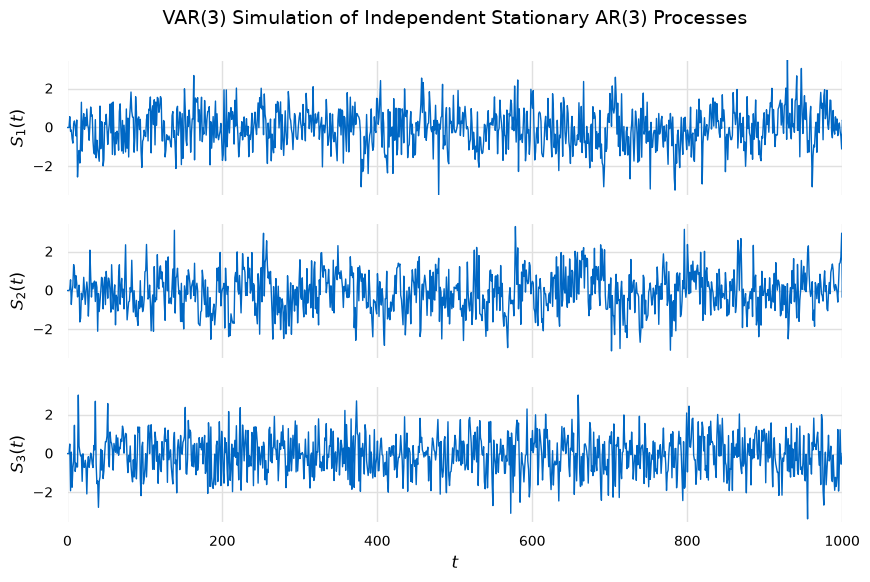

In [40]:
title = f"VAR(3) Simulation of Independent Stationary AR(3) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [41]:
result, result_model = var.compute_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.1446,0.1485,1.156,0.1460
1,0.07209,0.08774,1.075,0.07758
2,0.04622,0.07361,1.047,0.05582
3,-0.009798*,0.02933*,0.9903*,0.003917*
4,-0.007753,0.04312,0.9923,0.01008


In [42]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "bae75b59-c1e2-48fc-9fca-cd4b1b21b819",
   "_VAROrderTestReport__order": {
      "test_id": "bae75b59-c1e2-48fc-9fca-cd4b1b21b819",
      "label": "$\\tau_{min}$",
      "value": 3
   },
   "_VAROrderTestReport__aic": {
      "test_id": "bae75b59-c1e2-48fc-9fca-cd4b1b21b819",
      "order": {
         "test_id": "bae75b59-c1e2-48fc-9fca-cd4b1b21b819",
         "label": "$\\tau_{AIC}$",
         "value": 3
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "bae75b59-c1e2-48fc-9fca-cd4b1b21b819",
         "label": "$\\varepsilon_{AIC}$",
         "value": -0.009797852544537938
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "bae75b59-c1e2-48fc-9fca-cd4b1b21b819",
      "order": {
         "test_id": "bae75b59-c1e2-48fc-9fca-cd4b1b21b819",
         "label": "$\\tau_{BIC}$",
         "value": 3
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "bae75b59-c1e2-48fc-9fca-cd4b1b21b819",
      

In [43]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 23, Aug, 2026
Time:                     17:31:21
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                  0.0288443
Nobs:                     4997.00    HQIC:                0.00343368
Log likelihood:          -21215.6    FPE:                   0.989774
AIC:                   -0.0102787    Det(Omega_mle):        0.983855
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.005159         0.014003           -0.368           0.713
L1.y1         0.153045         0.013957           10.966           0.000
L1.y2         0.015104         0.013723            1.101           0.271
L1.y3         0.002768

In [44]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VAR",
   "const": [
      {
         "est": -0.005159189761570032,
         "err": 0.01400261902147701,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "06cff94d-6aad-4168-aca5-f3b709080de1",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.015767265131091758,
         "err": 0.014250309641607735,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 2,
         "est_id": "06cff94d-6aad-4168-aca5-f3b709080de1",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.03477440786220579,
         "err": 0.01420506633659879,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 3,
         "est_id": "06cff94d-6aad-4168-aca5-f3b709080de1",
         "param_type": "VAR_CONST"
    

### Coupled $\text{AR}(3)$

In [45]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.1, 0.2],
                      [0.0, 0.15, 0.1],
                      [0.05, 0.025, 0.05]]),
        numpy.matrix([[0.015, 0.01, 0.0],
                      [0.1, 0.1, 0.05],
                      [0.1, 0.05, 0.05]]),
        numpy.matrix([[0.15, 0.05, 0.1],
                      [0.0, 0.15, 0.025],
                      [0.025, 0.15, 0.05]])])
mu = numpy.array([0.0, 0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0, 0.0],
                      [0.0, 1.0, 0.0],
                      [0.0, 0.0, 1.0]])
npts=5000
nlag=3
var.compute_is_stationary(phi)


True

In [46]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

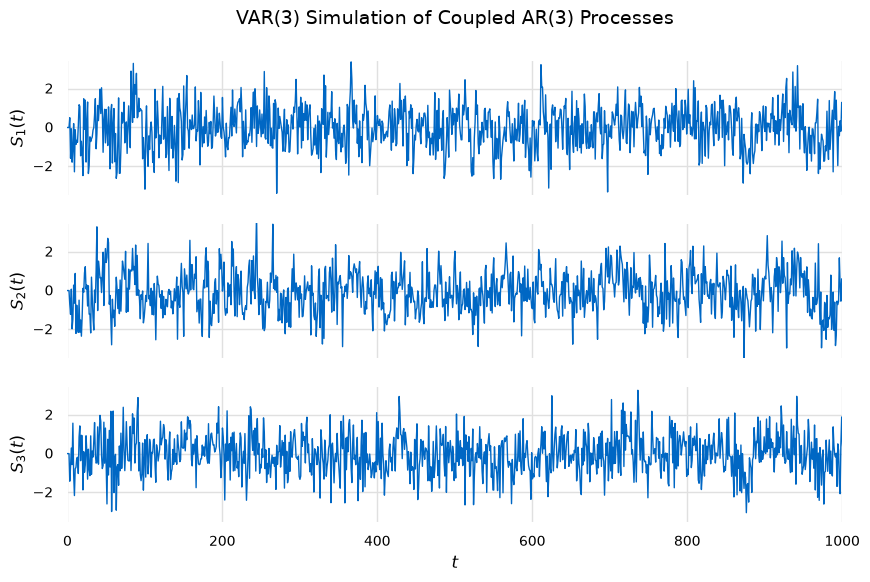

In [47]:
title = f"VAR(3) Simulation of Coupled AR(3) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [48]:
result, result_model = var.compute_order(xt, maxlags=5)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.4400,0.4439,1.553,0.4414
1,0.1951,0.2108,1.215,0.2006
2,0.1123,0.1397,1.119,0.1219
3,0.04447*,0.08361*,1.045*,0.05819*
4,0.04667,0.09755,1.048,0.06451
5,0.04761,0.1102,1.049,0.06956


In [49]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "1f8b16dc-e34a-469d-b298-504afd9cd3f8",
   "_VAROrderTestReport__order": {
      "test_id": "1f8b16dc-e34a-469d-b298-504afd9cd3f8",
      "label": "$\\tau_{min}$",
      "value": 3
   },
   "_VAROrderTestReport__aic": {
      "test_id": "1f8b16dc-e34a-469d-b298-504afd9cd3f8",
      "order": {
         "test_id": "1f8b16dc-e34a-469d-b298-504afd9cd3f8",
         "label": "$\\tau_{AIC}$",
         "value": 3
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "1f8b16dc-e34a-469d-b298-504afd9cd3f8",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.04447450396518175
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "1f8b16dc-e34a-469d-b298-504afd9cd3f8",
      "order": {
         "test_id": "1f8b16dc-e34a-469d-b298-504afd9cd3f8",
         "label": "$\\tau_{BIC}$",
         "value": 3
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "1f8b16dc-e34a-469d-b298-504afd9cd3f8",
        

In [50]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 23, Aug, 2026
Time:                     17:31:22
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                  0.0835123
Nobs:                     4997.00    HQIC:                 0.0581017
Log likelihood:          -21352.2    FPE:                    1.04539
AIC:                    0.0443893    Det(Omega_mle):         1.03914
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.015146         0.014371           -1.054           0.292
L1.y1         0.147389         0.013952           10.564           0.000
L1.y2         0.131089         0.014191            9.238           0.000
L1.y3         0.196682

In [51]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VAR",
   "const": [
      {
         "est": -0.015145875035001866,
         "err": 0.014371458051245655,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "3f3cd660-6d92-4b60-86c6-ad1ec003bc1f",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.0007966269619900472,
         "err": 0.014228285831542797,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 2,
         "est_id": "3f3cd660-6d92-4b60-86c6-ad1ec003bc1f",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.012958827940761974,
         "err": 0.014177092371240716,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma^M$",
         "row": 0,
         "column": 0,
         "order": 3,
         "est_id": "3f3cd660-6d92-4b60-86c6-ad1ec003bc1f",
         "param_type": "VAR_CONST"
 